# Download and prepare `SW_IN` (2004-2025)

**notebook version**: `6` (19 Jul 2026)

## ℹ️ About this notebook

Downloads screened `SW_IN` from the InfluxDB database, merges the three data sources into one
continuous series, corrects a known logger timestamp shift, gap-fills the result and stores it
to the external data folder for use by notebook `11`.

**Output columns:**

- `SW_IN_T1_47_1_gfXG` — the gap-filled series (W m⁻², complete, non-negative)
- `FLAG_SW_IN_T1_47_1_ISFILLED` — how each record was obtained; `0` = measured, `>0` = filled
  (see `FLAG_LEGEND` below for the individual codes)

**Fill quality is not the same across the record.** Daytime gaps 2004-2018 are filled with the
NABEL pyranometer as an extra driver. 2019-2025 has no second radiation sensor, so those fills
are only a typical value for the time of day and year. Details in the 2019-2025 section.

Downloading uses diive's in-house InfluxDB engine `InfluxIO`. It needs `influxdb-client`, which
a plain `uv sync` installs here via the `diive[db]` extra — nothing extra to set up. (Note that
diive's own `uv sync --group db` does not reach this project: dependency groups are local to the
project that declares them, so the extra is what crosses over.)

***

# Info about data sources

- `SW_IN`: NABEL (2004-2018), mst (2005-2021), diive (2022-2025)
- ETH data are the main data
- NABEL data are used to gap-fill ETH data to create a complete time series 2004-2018
- ETH data 2019-2025 is gap-filled separately, using only `SW_IN_POT`+
- Gap-filling is done using XGBoost, it also uses e.g. timestamp and potential radiation as features

Legend:
- NABEL ... Data from [NABEL](https://www.bafu.admin.ch/bafu/en/home/topics/air/luftbelastung/national-air-pollution-monitoring-network--nabel-.html), meteoscreening with [diive](https://github.com/holukas/diive)
- mst ... Data from ETH, meteoscreening with the now deprecated MeteoscreeningTool
- diive ... Data from ETH, meteoscreening with diive

## ⏱️ Timestamp convention

The database stores every timestamp in **UTC** and as **`TIMESTAMP_END`**. On download, `InfluxIO`
shifts the UTC timestamp by `TIMEZONE_OFFSET_TO_UTC_HOURS`, so the returned data are in **local
time** (UTC + offset) and still `TIMESTAMP_END`. `TimestampSanitizer(output_middle_timestamp=True)`
then converts to `TIMESTAMP_MID`, which is what the rest of this notebook works with.

`START` and `STOP` are interpreted in the same timezone as `TIMEZONE_OFFSET_TO_UTC_HOURS`.

***

# ⚙️ Settings

## Data settings

In [1]:
DIRCONF = r'F:\dev\poet\configs'
# DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'  # Folder with configuration files: needed e.g. for connection to database
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # Timezone, e.g. "1" is translated to timezone "UTC+01:00" (CET, winter time)
REQUIRED_TIME_RESOLUTION = '30min'  # Expected resolution; TimestampSanitizer raises if the data disagree
SITE_LAT = 47.478333  # CH-LAE
SITE_LON = 8.364389  # CH-LAE

# Output: data files live in the external (untracked) data folder, with the same
# numeric prefix as this notebook.
OUTNAME = "01_METEO_SW_IN_GAPFILLED_2004-2025"
OUTPATH = r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS"

## Imports

In [2]:
from datetime import datetime
from pathlib import Path
import importlib.metadata

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme('notebook')

import diive as dv
from diive.core.io.db.influx import InfluxIO  # diive's in-house InfluxDB engine (via the diive[db] extra)
from diive.core.times.times import TimestampSanitizer

import warnings

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)

# Start time is kept so the last cell can report the total runtime of the notebook.
NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive version: v{importlib.metadata.version('diive')}")

Last run: 2026-07-19 23:23:43
diive version: v0.91.0


In [3]:
# Result flags of SWINGapFillerXGBoost, see the class docstring.
FLAG_LEGEND = {
    0: '0 = observed',
    1: '1 = daytime gap, filled by the XGBoost model',
    2: '2 = daytime gap, filled by the timestamp-only fallback model (a driver was missing)',
    3: '3 = nighttime gap, set to zero by physics',
    4: '4 = daytime gap, filled by clearness-index interpolation',
}

## Plot helpers

In [4]:
# Diagnostic plots for the gap-filling runs. Defined once, used after every run.

def plot_gapfill_panels(results, title, ylabel=r'$\mathrm{W\ m^{-2}}$', figsize=(16, 7)):
    """Three stacked panels: measured only, the final series, and the fills on their own.

    The third panel is the one to look at. Fills are shown against a blank background, so
    a fill that sits at the wrong level, or a block of fills where there should be none,
    is immediately visible instead of being hidden under the measured series.
    """
    gapfilled = results.gapfilled
    flag = results.flag
    _plotdf = pd.DataFrame({
        'observed': gapfilled.where(flag == 0),
        'gapfilled': gapfilled,
        'gap values': gapfilled.where(flag > 0),
    })
    axs = _plotdf.plot(subplots=True, figsize=figsize, x_compat=True, alpha=.9,
                       title=title, legend=True)
    for ax in axs:
        ax.set_ylabel(ylabel)
    plt.tight_layout()
    return axs


def fill_stats_by_year(flag, legend=None):
    """Records per year and flag, plus a stacked bar chart of the filled ones."""
    legend = legend or FLAG_LEGEND
    tab = (pd.crosstab(flag.index.year, flag)
             .rename(columns=lambda f: legend.get(f, f))
             .rename_axis(index='year', columns=None))
    filled = tab.drop(columns=[c for c in tab.columns if str(c).startswith('0 =')],
                      errors='ignore')
    if not filled.empty and filled.to_numpy().sum() > 0:
        ax = filled.plot(kind='bar', stacked=True, figsize=(14, 4),
                         title='Filled records per year')
        ax.set_ylabel('records')
        ax.legend(fontsize=8)
        plt.tight_layout()
    return tab


def plot_fill_overview(series, flag, label, ylabel=r'$\mathrm{W\ m^{-2}}$'):
    """Four-panel overview of the final series: where the fills are and how they behave.

    Panels: flag over date/time-of-day; monthly means of the full series against the
    measured-only series (a gap between the two lines means the fills are biased);
    cumulative sum; and the share of filled records per month.
    """
    fig = plt.figure(figsize=(18, 9), dpi=100, layout='constrained')
    gs = gridspec.GridSpec(2, 2, figure=fig)
    fig.suptitle(f'Gap-filling overview: {label}', fontsize=15)

    ax = fig.add_subplot(gs[:, 0])
    dv.plotting.HeatmapDateTime(series=flag.astype(float)).plot(
        ax=ax, cb_digits_after_comma=0, zlabel='flag',
        format_style=dv.plotting.FormatStyle(title='Flag (0 = measured)', title_fontsize=11))

    measured = series.where(flag == 0)
    ax = fig.add_subplot(gs[0, 1])
    series.resample('MS').mean().plot(ax=ax, label='all records', lw=1.2)
    measured.resample('MS').mean().plot(ax=ax, label='measured only', lw=1.2, ls='--')
    ax.set_title('Monthly means', fontsize=11)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

    ax = fig.add_subplot(gs[1, 1])
    share = (flag > 0).resample('MS').mean() * 100
    ax.fill_between(share.index, share.values, step='mid', alpha=.7)
    ax.set_title('Share of filled records per month', fontsize=11)
    ax.set_ylabel('%')
    return fig


def plot_pred_vs_measured(model, title, unit=r'$\mathrm{W\ m^{-2}}$'):
    """Predicted against measured on the HELD-OUT test set, plus residuals.

    This is the only honest validation view available: `gapfilled` equals the measurement
    wherever the flag is 0, so plotting those against each other would just draw the 1:1
    line. `daytime_model_.traintest_details_` keeps the test records the model never saw
    during training, which is what these panels use.

    Left: measured vs predicted, 1:1 line in red. Right: residual against prediction —
    a tilt means bias, a widening cone means the error scales with magnitude.
    """
    if model is None:
        print("No model available (no daytime gaps) - nothing to validate.")
        return
    test = model.traintest_details_['test_df']
    measured = test[model.target_col].values
    predicted = model.model_.predict(test.drop(columns=model.target_col))
    residual = predicted - measured
    rmse = float(np.sqrt((residual ** 2).mean()))
    bias = float(residual.mean())

    fig, axs = plt.subplots(ncols=2, figsize=(13, 5.5), dpi=100, layout='constrained')
    fig.suptitle(f"{title}  (held-out test set, n={len(test):,})", fontsize=13)

    axs[0].hexbin(measured, predicted, gridsize=60, mincnt=1, bins='log', cmap='viridis')
    lim = [float(min(measured.min(), predicted.min())), float(max(measured.max(), predicted.max()))]
    axs[0].plot(lim, lim, 'r-', lw=1.2, label='1:1')
    axs[0].set_xlabel(f'measured {unit}')
    axs[0].set_ylabel(f'predicted {unit}')
    axs[0].set_title(f'RMSE {rmse:.2f}   bias {bias:+.2f}', fontsize=11)
    axs[0].legend(fontsize=8)

    axs[1].hexbin(predicted, residual, gridsize=60, mincnt=1, bins='log', cmap='viridis')
    axs[1].axhline(0, color='r', lw=1.2)
    axs[1].set_xlabel(f'predicted {unit}')
    axs[1].set_ylabel(f'residual (predicted - measured) {unit}')
    axs[1].set_title('Residuals', fontsize=11)
    return fig

## 🔌 Connect to database

In [5]:
dbc = InfluxIO(dirconf=DIRCONF)

> Reading configuration files was successful.

v Connection to database works.

***

# ⬇️ `NABEL` data (2004-2018) and ETH data (2022-2025) from `diive` meteoscreening

## Download

In [6]:
%%time

BUCKET = f'ch-lae_processed'
FIELDS = ['SW_IN_NABEL_T1_49_1', 'SW_IN_T1_47_1']
MEASUREMENTS = ['SW']
START = '2004-01-01 00:00:01'
STOP = '2026-01-01 00:00:01'
DATA_VERSION = 'meteoscreening_diive'

nabel_eth_diive_swin_2004_2018_2022_2025, _, _ = dbc.download(
    bucket=BUCKET,
    measurements=MEASUREMENTS,
    fields=FIELDS,
    start=START,  # Download data starting with this date (the start date itself IS included),
    stop=STOP,  # Download data before this date (the stop date itself IS NOT included),
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version=DATA_VERSION
)

> DOWNLOADING from bucket ch-lae_processed: variables ['SW_IN_NABEL_T1_49_1', 'SW_IN_T1_47_1'] 
from measurements ['SW'], data version ['meteoscreening_diive'], between 2004-01-01 00:00:01 and 
2026-01-01 00:00:01 (timezone offset to UTC 1)

> Downloaded data for 2 variables:

CPU times: total: 6.22 s
Wall time: 8.56 s


In [7]:
nabel_eth_diive_swin_2004_2018_2022_2025

,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1
TIMESTAMP_END,,
2004-01-01 00:30:00,NaN,0.0
2004-01-01 01:00:00,NaN,0.0
2004-01-01 01:30:00,NaN,0.0
2004-01-01 02:00:00,NaN,0.0
2004-01-01 02:30:00,NaN,0.0
...,...,...
2025-12-31 22:00:00,0.0,NaN
2025-12-31 22:30:00,0.0,NaN
2025-12-31 23:00:00,0.0,NaN


## Sanitize timestamp

In [8]:
nabel_eth_diive_swin_2004_2018_2022_2025 = TimestampSanitizer(
    data=nabel_eth_diive_swin_2004_2018_2022_2025,
    output_middle_timestamp=True,
    nominal_freq=REQUIRED_TIME_RESOLUTION,  # raises ValueError if the data are not 30MIN
).get()
nabel_eth_diive_swin_2004_2018_2022_2025

,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,0.0
2004-01-01 00:45:00,NaN,0.0
2004-01-01 01:15:00,NaN,0.0
2004-01-01 01:45:00,NaN,0.0
2004-01-01 02:15:00,NaN,0.0
...,...,...
2025-12-31 21:45:00,0.0,NaN
2025-12-31 22:15:00,0.0,NaN
2025-12-31 22:45:00,0.0,NaN


***

# ⬇️ Data from `mst` meteoscreening (2004-2021)

## Download

In [9]:
%%time

BUCKET = f'ch-lae_processed'
FIELDS = ['SW_IN_T1_47_1']
MEASUREMENTS = ['SW']
START = '2004-01-01 00:00:01'
STOP = '2022-01-01 00:00:01'
DATA_VERSION = 'meteoscreening_mst'

mst_swin_2004_2021, _, _ = dbc.download(
    bucket=BUCKET,
    measurements=MEASUREMENTS,
    fields=FIELDS,
    start=START,  # Download data starting with this date (the start date itself IS included),
    stop=STOP,  # Download data before this date (the stop date itself IS NOT included),
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version=DATA_VERSION
)

> DOWNLOADING from bucket ch-lae_processed: variables ['SW_IN_T1_47_1'] from measurements ['SW'], 
data version ['meteoscreening_mst'], between 2004-01-01 00:00:01 and 2022-01-01 00:00:01 (timezone 
offset to UTC 1)

> Downloaded data for 1 variables:

CPU times: total: 4.55 s
Wall time: 6.7 s


In [10]:
mst_swin_2004_2021

,SW_IN_T1_47_1
TIMESTAMP_END,
2005-09-14 11:30:00,0.000000
2005-09-14 12:00:00,25.692612
2005-09-14 13:30:00,645.754150
2005-09-14 14:00:00,314.615936
2005-09-14 14:30:00,220.304276
...,...
2021-12-31 22:00:00,-9.935194
2021-12-31 22:30:00,-10.250348
2021-12-31 23:00:00,-9.810373


## Sanitize timestamp

In [11]:
mst_swin_2004_2021 = TimestampSanitizer(
    data=mst_swin_2004_2021,
    output_middle_timestamp=True,
    nominal_freq=REQUIRED_TIME_RESOLUTION,  # raises ValueError if the data are not 30MIN
).get()
mst_swin_2004_2021

,SW_IN_T1_47_1
TIMESTAMP_MIDDLE,
2005-09-14 11:15:00,0.000000
2005-09-14 11:45:00,25.692612
2005-09-14 12:15:00,NaN
2005-09-14 12:45:00,NaN
2005-09-14 13:15:00,645.754150
...,...
2021-12-31 21:45:00,-9.935194
2021-12-31 22:15:00,-10.250348
2021-12-31 22:45:00,-9.810373


***

# ❇️ Merge data

ETH data from `diive` meteoscreening (2022-2025) are the main data, gaps before 2022 are
filled in from the `mst` meteoscreening.

In [12]:
# Merge data on index
swin_2004_2025 = nabel_eth_diive_swin_2004_2018_2022_2025.copy()
swin_2004_2025['SW_IN_T1_47_1'] = swin_2004_2025['SW_IN_T1_47_1'].combine_first(mst_swin_2004_2021['SW_IN_T1_47_1'])
swin_2004_2025

,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,0.0
2004-01-01 00:45:00,NaN,0.0
2004-01-01 01:15:00,NaN,0.0
2004-01-01 01:45:00,NaN,0.0
2004-01-01 02:15:00,NaN,0.0
...,...,...
2025-12-31 21:45:00,0.0,NaN
2025-12-31 22:15:00,0.0,NaN
2025-12-31 22:45:00,0.0,NaN


## Sanitize timestamp

In [13]:
swin_2004_2025 = TimestampSanitizer(data=swin_2004_2025, output_middle_timestamp=True).get()
swin_2004_2025

,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,0.0
2004-01-01 00:45:00,NaN,0.0
2004-01-01 01:15:00,NaN,0.0
2004-01-01 01:45:00,NaN,0.0
2004-01-01 02:15:00,NaN,0.0
...,...,...
2025-12-31 21:45:00,0.0,NaN
2025-12-31 22:15:00,0.0,NaN
2025-12-31 22:45:00,0.0,NaN


## Heatmap

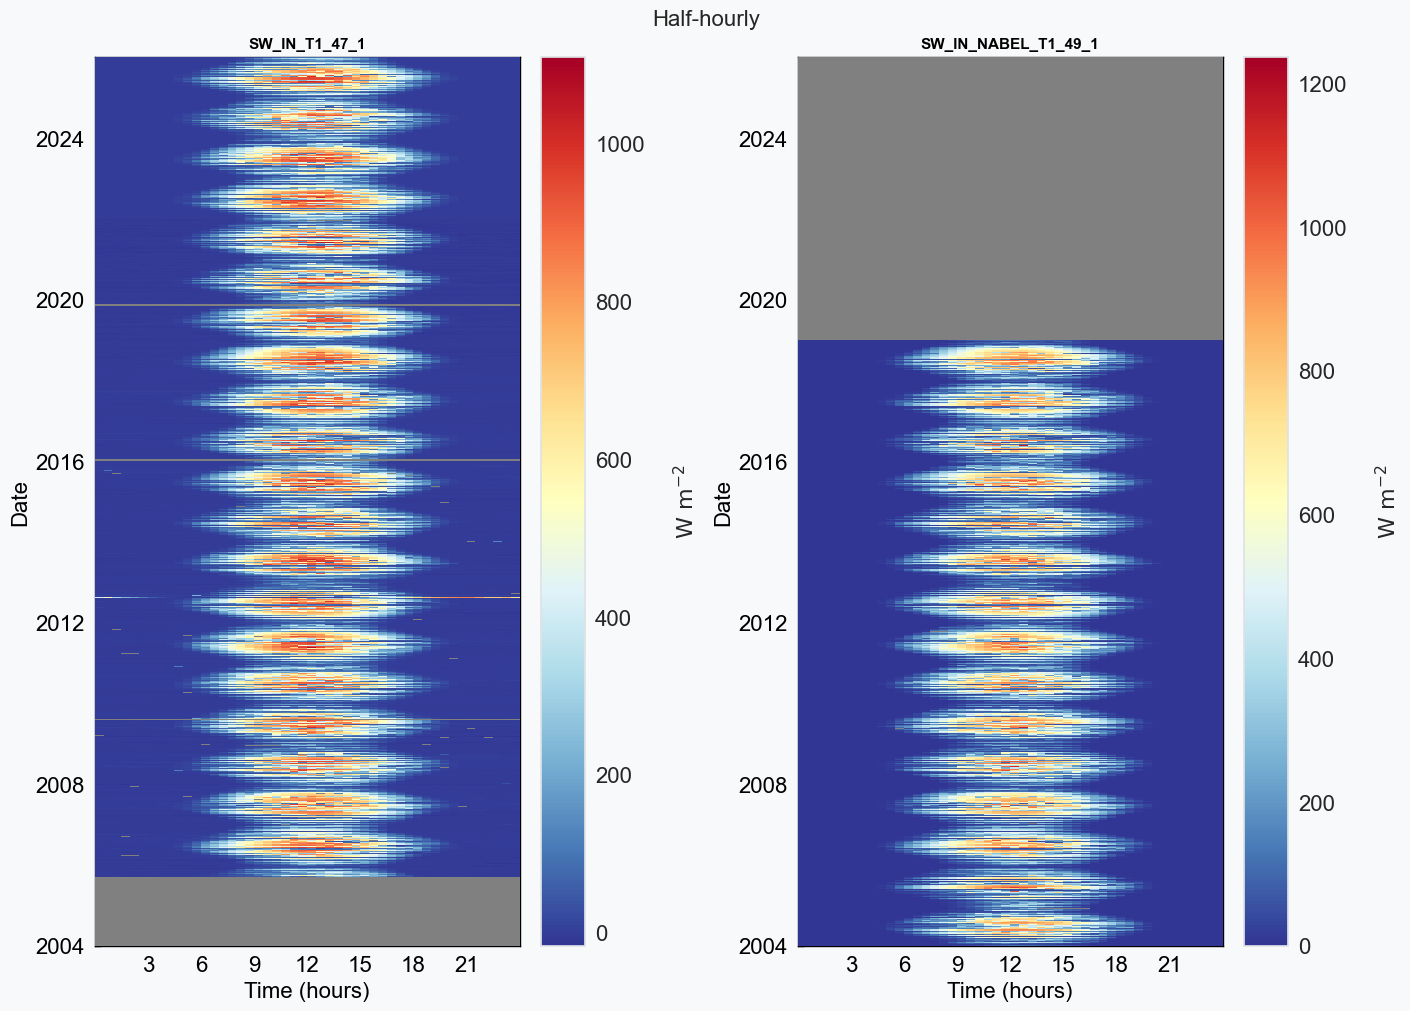

In [14]:
fig, axs = plt.subplots(ncols=2, figsize=(14, 10), dpi=100, layout="constrained")
fig.suptitle(f'Half-hourly', fontsize=16)
dv.plotting.HeatmapDateTime(series=swin_2004_2025['SW_IN_T1_47_1']).plot(
    ax=axs[0], cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
    format_style=dv.plotting.FormatStyle(title="SW_IN_T1_47_1", title_fontsize=11))
dv.plotting.HeatmapDateTime(series=swin_2004_2025['SW_IN_NABEL_T1_49_1']).plot(
    ax=axs[1], cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
    format_style=dv.plotting.FormatStyle(title="SW_IN_NABEL_T1_49_1", title_fontsize=11))

***

# ✴️ Corrections

### Timestamp shift in August 2012
**Info from fieldbook entry 17 Aug 2012:**
>   adjusted the logger date and time. On Servertime (Computer System Time) 17.08.2012 12:31.42 the loggertime was 16.08.2012 08:06:00. Synchronized time at 17.08.2012 11:40:00 servertime. The logger data aquisition on the moxa embedded was restarted

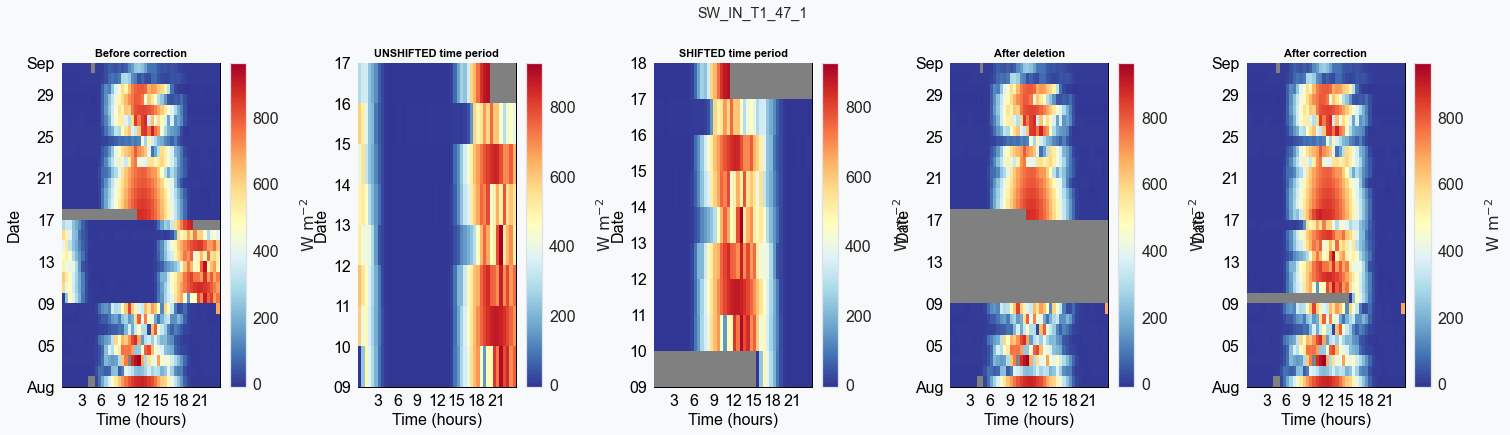

In [15]:
AFFECTED_VARS = ['SW_IN_T1_47_1']
_df = swin_2004_2025.copy()

for av in AFFECTED_VARS:
    fig = plt.figure(figsize=(24, 6), dpi=72)
    fig.suptitle(f"{av}")
    gs = gridspec.GridSpec(1, 5)  # rows, cols
    gs.update(wspace=0.5, hspace=1, left=.1, right=.9, top=.85, bottom=.1)
    ax_before = fig.add_subplot(gs[0, 0])
    ax_unshifted = fig.add_subplot(gs[0, 1])
    ax_shifted = fig.add_subplot(gs[0, 2])
    ax_after = fig.add_subplot(gs[0, 3])
    ax_corrected = fig.add_subplot(gs[0, 4])

    # Show time period around issue, before correction
    _show_locs = (_df.index >= '2012-08-01 00:00') & (_df.index <= '2012-09-01 00:00')
    dv.plotting.HeatmapDateTime(series=_df.loc[_show_locs, av]).plot(
        ax=ax_before, cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
        format_style=dv.plotting.FormatStyle(title="Before correction", title_fontsize=11))

    # Get shifted time period
    _series_corrected = _df.loc[_show_locs, av].copy()
    # Identify shifted time period
    ISSUE_START = '2012-08-09 00:00'
    ISSUE_END = '2012-08-17 00:00'
    _shifted_locs = (_df.index >= ISSUE_START) & (_df.index <= ISSUE_END)
    _series_shifted = _df.loc[_shifted_locs, av].copy()
    _series_shifted = _series_shifted.dropna()
    dv.plotting.HeatmapDateTime(series=_series_shifted).plot(
        ax=ax_unshifted, cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
        format_style=dv.plotting.FormatStyle(title="UNSHIFTED time period", title_fontsize=11))

    # Shift SW_IN by 15.5 hours during shifted time period, create corrected time series
    _series_shifted.index = _series_shifted.index + pd.Timedelta(hours=15.5)
    dv.plotting.HeatmapDateTime(series=_series_shifted).plot(
        ax=ax_shifted, cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
        format_style=dv.plotting.FormatStyle(title="SHIFTED time period", title_fontsize=11))

    # Delete data between start of issue and the last timestamp of shifted data
    _overwrite_locs = (_df.index >= ISSUE_START) & (_df.index <= _series_shifted.index[-1])
    _df.loc[_overwrite_locs, av] = np.nan
    dv.plotting.HeatmapDateTime(series=_df.loc[_show_locs, av]).plot(
        ax=ax_after, cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
        format_style=dv.plotting.FormatStyle(title="After deletion", title_fontsize=11))

    # Fill in corrected values
    _df.loc[_overwrite_locs, av] = _series_shifted
    dv.plotting.HeatmapDateTime(series=_df.loc[_show_locs, av]).plot(
        ax=ax_corrected, cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
        format_style=dv.plotting.FormatStyle(title="After correction", title_fontsize=11))

In [16]:
swin_2004_2025 = _df.copy()
swin_2004_2025

,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,0.0
2004-01-01 00:45:00,NaN,0.0
2004-01-01 01:15:00,NaN,0.0
2004-01-01 01:45:00,NaN,0.0
2004-01-01 02:15:00,NaN,0.0
...,...,...
2025-12-31 21:45:00,0.0,NaN
2025-12-31 22:15:00,0.0,NaN
2025-12-31 22:45:00,0.0,NaN


### Power failure, late July to mid August 2012

The timestamp shift above is not the only problem in August 2012. Aligning `SW_IN_T1_47_1`
against the NABEL sensor day by day, and searching for the time lag that agrees best, gives:

| date | best lag | RMSE at best lag | RMSE at zero lag |
|---|---|---|---|
| 2012-07-28 | 0 | 37 | 37 |
| 2012-07-31 | 0 | 70 | 70 |
| 2012-08-02 | 0 | 156 | 156 |
| 2012-08-06 | -25.0 h | 181 | 208 |
| 2012-08-09 | -32.5 h | 116 | 467 |
| **2012-08-10** | **+15.5 h** | **60** | 565 |
| **2012-08-14** | **+15.5 h** | **42** | 503 |
| **2012-08-16** | **+15.5 h** | **55** | 420 |
| 2012-08-17 | -24.5 h | 122 | 249 |
| 2012-08-18 | 0 | 8 | 8 |

Two different faults:

- **10 to 16 August** locks onto exactly `+15.5 h` and the error collapses from ~500 to 42-60
  W m-2. That is the logger clock, and the correction above fixes it.
- **29 July to 9 August** degrades steadily (RMSE 57 -> 70 -> 134 -> 156 -> 467) and **no time
  shift repairs it**. The apparent best lags there are around +/-24 h, which are aliases: shifting
  a daily cycle by about a day roughly realigns it, and even then the error only falls to 115-230
  W m-2 rather than to the 42-60 seen in the genuine shift window. 17 August is likewise
  transitional.

The fieldbook gives the cause, and dates the repair to the day the degradation ends:

> **09.08.2012** Fixed the power problem on the tower: replaced battery and replaced some fuses
> (there were many falsely placed or broken) and replaced the whole power supply
>
> **10.08.2012** Some problems remain with logger, maybe it's the WLAN (could not log in the last
> two weeks), restared programs

"could not log in the last two weeks" puts the onset around 27 July, which matches the 29 July
seen in the data. `TA_T1_47_1`, a different instrument on the same acquisition system, degrades
over the same window (RMSE 1.2-3.2 degC against a 0.7-0.9 degC baseline) and is likewise not
repaired by any constant lag — consistent with a supply fault upstream of both sensors rather
than with either sensor failing.

Those records cannot be repaired, only removed. Over 29 July to 9 August the daytime mean is
309 W m-2 at 47 m against 402 W m-2 at NABEL, individual half-hours differ by up to 933 W m-2,
and the error does not even keep a consistent sign: on 2 August the daytime mean is 188 against
374 at NABEL, while on 6 August it is 194 against 126. Left in place these would enter the
product labelled as measured. They are therefore deleted here and gap-filled afterwards from
NABEL, which is what the gap-filler does well (~37 W m-2 per record).

All windows below are given on the **corrected** time axis. The first runs to 10 August 15:30
rather than to 9 August, because the shift moves the questionable 9 August readings forward by
15.5 h; the second covers the untrustworthy tail after the last shifted value; the third is the
October-November period described next.
### Storm damage, late October to early November 2012

A third damaged period, found by the same day-by-day lag search:

| date | best lag | RMSE at best lag | RMSE at zero lag |
|---|---|---|---|
| 2012-10-27 | 0 | 6.4 | 6.4 |
| 2012-10-28 | 0 | 143.3 | 143.3 |
| 2012-10-30 | 0 | 214.4 | 214.4 |
| 2012-11-05 | -3.0 h | 177.1 | 182.3 |
| 2012-11-08 | 0 | 71.4 | 71.4 |
| 2012-11-10 | 0 | 15.6 | 15.6 |

Shifting in time barely helps on any day here — where a lag does come out lowest the gain is a
few hundredths — so unlike August this is not a clock problem. The fieldbook records storm damage
and cable work in exactly this window:

> **01.11.2012** Checked Forestfloor and Hut for broken sensors due to fallen trees and big branches
>
> **06.11.2012** checked all sensor cables. especialy the cables at the forest floor are sometimes
> strongly stressed. tried to unstress the cables

The data return to normal from 10 November, right after that visit. Note that both entries name
the *forest floor* sensors rather than the 47 m instruments, so the link is circumstantial: what
is certain is that a storm hit the site, that cables were found stressed, and that the recovery
follows the repair visit. `SW_IN_T1_47_1` and `TA_T1_47_1` are affected together over the same
days, which again points at something shared rather than at one instrument.

The fieldbook also notes on **30.10.2012** that the MOXA was "running on wrong time base: CEST
instead of CET", fixed at 10:11 that day. Swiss daylight saving ended on 28 October, so
timestamps could have been an hour ahead for those two days — but no such offset is detectable
in the data (it would show as a best lag of -2 records, and it does not), and in any case the
whole period is removed below.

The affected records are deleted together with the August ones.

Removed 1214 degraded records from SW_IN_T1_47_1 (gap-filled later from NABEL).


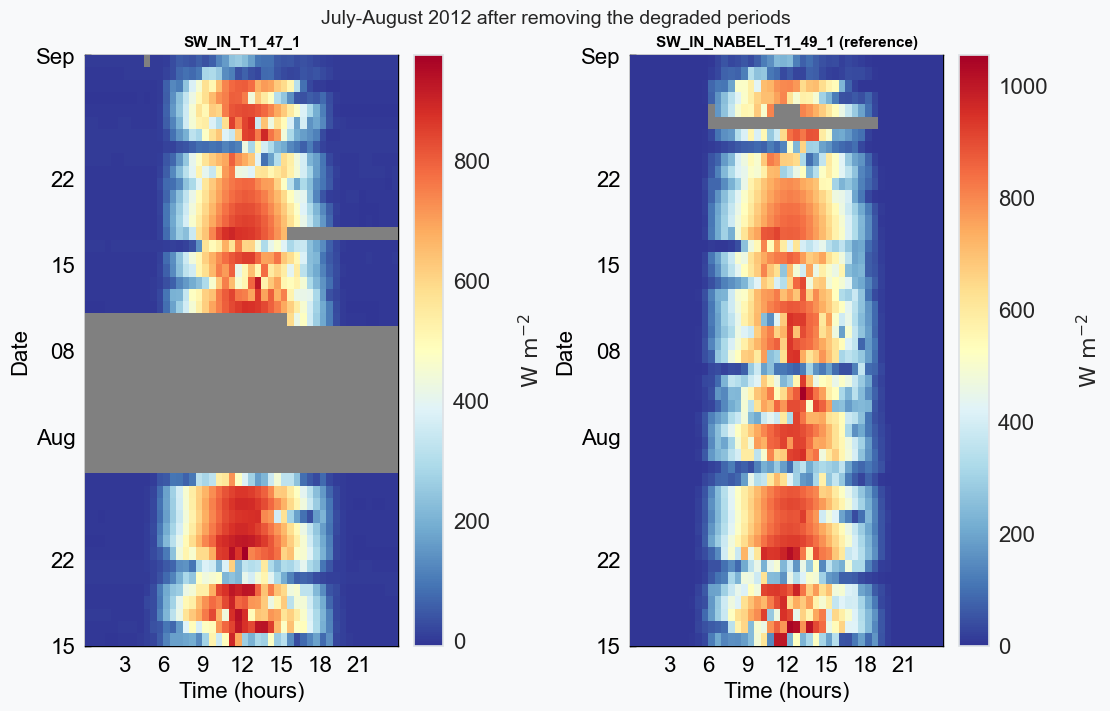

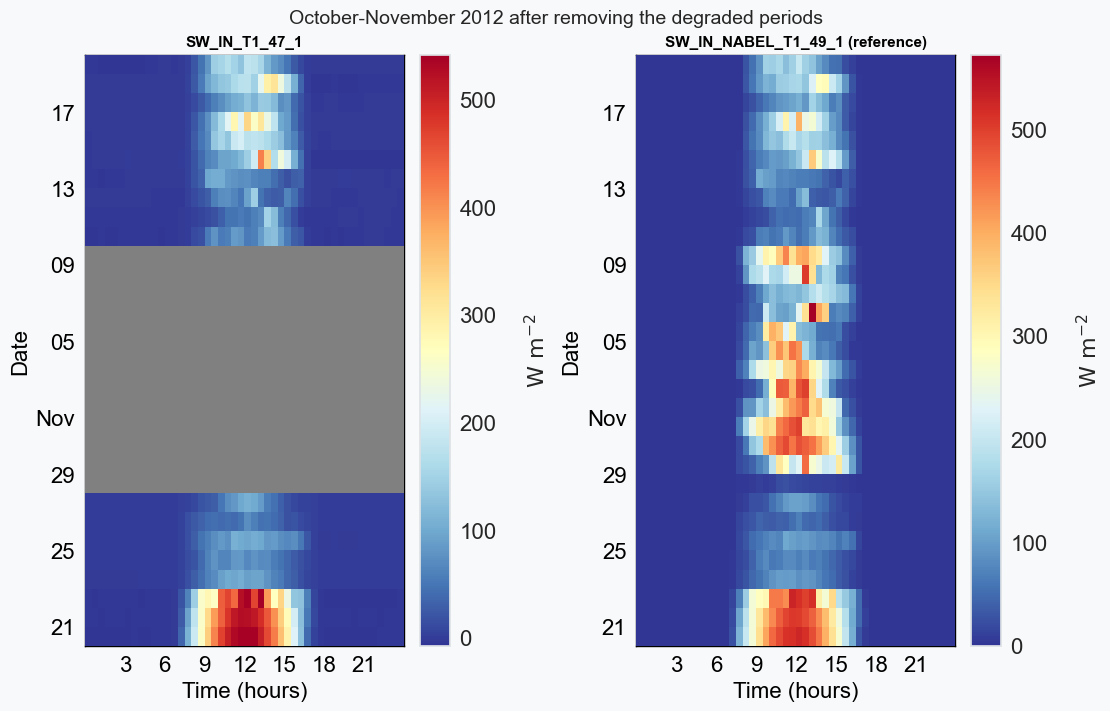

In [17]:
# Three damaged periods in 2012, all documented in the fieldbook and none repairable.
# Windows are on the CORRECTED time axis (i.e. after the +15.5 h shift above).
BAD_WINDOWS_2012 = [
    ('2012-07-29 00:00', '2012-08-10 15:30'),  # tower power supply failure (fieldbook 09.08.2012)
    ('2012-08-17 15:30', '2012-08-18 00:00'),  # transitional tail after the last shifted value
    ('2012-10-28 00:00', '2012-11-10 00:00'),  # storm damage, stressed cables (fieldbook 01./06.11.2012)
]
DEGRADED_VAR = 'SW_IN_T1_47_1'

_before = int(swin_2004_2025[DEGRADED_VAR].notna().sum())
for _start, _end in BAD_WINDOWS_2012:
    _locs = (swin_2004_2025.index >= _start) & (swin_2004_2025.index <= _end)
    swin_2004_2025.loc[_locs, DEGRADED_VAR] = np.nan
_removed = _before - int(swin_2004_2025[DEGRADED_VAR].notna().sum())
print(f"Removed {_removed} degraded records from {DEGRADED_VAR} (gap-filled later from NABEL).")

# One heatmap pair per affected period, with the NABEL sensor as the reference.
for _lo, _hi, _label in [('2012-07-15', '2012-09-01', 'July-August'),
                         ('2012-10-20', '2012-11-20', 'October-November')]:
    fig, axs = plt.subplots(ncols=2, figsize=(11, 7), dpi=100, layout="constrained")
    fig.suptitle(f'{_label} 2012 after removing the degraded periods', fontsize=14)
    _show = (swin_2004_2025.index >= _lo) & (swin_2004_2025.index <= _hi)
    dv.plotting.HeatmapDateTime(series=swin_2004_2025.loc[_show, DEGRADED_VAR]).plot(
        ax=axs[0], cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
        format_style=dv.plotting.FormatStyle(title=DEGRADED_VAR, title_fontsize=11))
    dv.plotting.HeatmapDateTime(series=swin_2004_2025.loc[_show, 'SW_IN_NABEL_T1_49_1']).plot(
        ax=axs[1], cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
        format_style=dv.plotting.FormatStyle(title='SW_IN_NABEL_T1_49_1 (reference)', title_fontsize=11))

::: {.callout-note title="Zero-offset correction"}
Version `3` of this notebook removed the `SW_IN` nighttime zero-offset here, with an explicit call
to `remove_radiation_zero_offset()`. That step is now done inside the gap-filler via
`correct_nighttime_offset=True` (see below), which applies the same correction
(`remove_nighttime_zero_offset()`) to each series before modelling. It is therefore no longer
done separately at this point.
:::

## Dataframe

In [18]:
display(swin_2004_2025)
swin_2004_2025.describe()

,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,0.0
2004-01-01 00:45:00,NaN,0.0
2004-01-01 01:15:00,NaN,0.0
2004-01-01 01:45:00,NaN,0.0
2004-01-01 02:15:00,NaN,0.0
...,...,...
2025-12-31 21:45:00,0.0,NaN
2025-12-31 22:15:00,0.0,NaN
2025-12-31 22:45:00,0.0,NaN


,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1
count,351726.000000,262774.000000
mean,141.864050,140.037811
std,239.528921,233.701783
min,-16.722927,0.000000
25%,-2.892479,0.000000
50%,1.288768,2.506354
75%,192.427765,186.456335
max,1109.351433,1236.721293


***

# 🟪 Prepare dataframes

Split into the two periods that are gap-filled separately: 2004-2018 (NABEL available as
driver) and 2019-2025 (no NABEL).

In [19]:
swin_2004_2018 = swin_2004_2025.loc[swin_2004_2025.index.year <= 2018].copy()
swin_2004_2018

,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,NaN,0.0
2004-01-01 00:45:00,NaN,0.0
2004-01-01 01:15:00,NaN,0.0
2004-01-01 01:45:00,NaN,0.0
2004-01-01 02:15:00,NaN,0.0
...,...,...
2018-12-31 21:45:00,-2.486487,0.0
2018-12-31 22:15:00,-2.620216,0.0
2018-12-31 22:45:00,-2.352738,0.0


In [20]:
swin_2019_2025 = swin_2004_2025.loc[swin_2004_2025.index.year >= 2019].copy()
swin_2019_2025 = swin_2019_2025.drop('SW_IN_NABEL_T1_49_1', axis=1)
swin_2019_2025

,SW_IN_T1_47_1
TIMESTAMP_MIDDLE,
2019-01-01 00:15:00,-2.149965
2019-01-01 00:45:00,-2.722333
2019-01-01 01:15:00,-3.087591
2019-01-01 01:45:00,-2.410228
2019-01-01 02:15:00,-2.400173
...,...
2025-12-31 21:45:00,0.000000
2025-12-31 22:15:00,0.000000
2025-12-31 22:45:00,0.000000


***

# 🟥 Gap-filling NABEL (2004-2018)

`SWINGapFillerXGBoost` computes `SW_IN_POT` from the site coordinates, uses it to separate day
from night, sets nighttime gaps to zero and fills daytime gaps with XGBoost.
`correct_nighttime_offset=True` removes the sensor's nighttime offset first, and negative values
are clipped to zero internally, so no manual correction is needed.

**Short daytime gaps** (up to 1 h) can be filled by interpolating between the neighbouring
measurements instead of using the model. This is done last and overwrites the model wherever it
applies, so it is only worth it when the model is the weaker of the two:

- **No second radiation sensor as driver** — the model knows nothing but the time of day and
  year, so interpolating from the neighbours is better.
- **A complete second sensor as driver** — the model is better, so interpolation is switched off.

The default `interpolate_short_gaps='auto'` decides this by checking whether a driver was passed
at all, not how complete that driver is. That fits two of the three runs. The exception is the
first run below: ETH is passed as a driver but has long gaps of its own before September 2005, so
interpolation is switched back on explicitly.

| Run | Driver (`context_df`) | Short-gap interpolation |
|---|---|---|
| NABEL 2004-2018 | ETH, has gaps | on (explicit) |
| ETH 2004-2018 | NABEL, gap-filled | off (`'auto'`) |
| ETH 2019-2025 | none | on (`'auto'`) |

The two 2004-2018 runs depend on each other: NABEL is filled using ETH, then ETH is filled using
the completed NABEL. Where both sensors are missing at the same time, the fill falls back to
time-of-day information only.

## Run gap-filling

In [21]:
%%time

TARGET = "SW_IN_NABEL_T1_49_1"

gf_nabel = dv.gapfilling.SWINGapFillerXGBoost(
    series=swin_2004_2018[TARGET],
    lat=SITE_LAT,
    lon=SITE_LON,
    utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS,
    context_df=swin_2004_2018[['SW_IN_T1_47_1']],  # ETH as additional driver (raw, still gappy here)
    correct_nighttime_offset=True,  # replaces the manual remove_radiation_zero_offset() step
    interpolate_short_gaps=2,  # explicit override of 'auto', see the note above
    reduce_features=True,
    verbose=1,
    # XGBoost hyperparameters are left at the class defaults (n_estimators, max_depth,
    # early_stopping_rounds, random_state). They are tuned for SW_IN and keep a run
    # reproducible; only n_jobs is set here.
    n_jobs=-1,
)
gf_nabel.run()

───────────────────────────── SW_IN Gap-Filling (SW_IN_NABEL_T1_49_1) ──────────────────────────────

> running remove_nighttime_zero_offset ...

Output()

> Step 1: Correcting nighttime sensor offset (2.2s)

Output()

...

> Step 7: Reducing features (SHAP vs random benchmark) and retraining (1.2s)

Output()

> Step 8: Filling daytime gaps (SHAP importances over full record) (8.3s)

v Done in 17.7s - 218 records filled (218 gaps total)

CPU times: total: 58.7 s
Wall time: 17.7 s


## Report

In [22]:
gf_nabel.report()

────────────────────────── SW_IN Gap-Filling Report: SW_IN_NABEL_T1_49_1 ───────────────────────────

Algorithm: physics-aware partitioning + XGBoost
    Nighttime gaps  -> set to 0 W m-2 (no incoming solar radiation)
    Daytime gaps    -> XGBoost trained on daytime observations
    Day/night split -> SW_IN_POT (potential radiation) vs threshold

──────────────────────────────────────────── Parameters ────────────────────────────────────────────

Site latitude              47.478333
  Site longitude             8.364389
  UTC offset                 1
  Nighttime threshold        0.001 W m-2  (SW_IN_POT < threshold -> night)
  Correct nighttime offset   True
  Reduce features (SHAP)     True
  context drivers            ['SW_IN_T1_47_1']

─────────────────────────────────────── Feature engineering ────────────────────────────────────────

...

MSE      1195.5738

RMSE     34.5771

MAPE     212583862718675.9688

MAXE     548.9246

R2       0.9829

## Results: scores and feature importances

In [23]:
r = gf_nabel.results
print("Daytime model, held-out (train/test) scores:")
display(pd.Series(r.scores_traintest))
print("Flag counts:")
display(r.flag.value_counts().sort_index().rename(index=FLAG_LEGEND))

Daytime model, held-out (train/test) scores:


mae      1.709537e+01
medae    6.323190e+00
mse      1.295960e+03
rmse     3.599944e+01
mape     2.020003e+14
maxe     5.482826e+02
r2       9.814259e-01
dtype: float64

Flag counts:


flag
0 = observed                                                                           262774
1 = daytime gap, filled by the XGBoost model                                              106
2 = daytime gap, filled by the timestamp-only fallback model (a driver was missing)        94
4 = daytime gap, filled by clearness-index interpolation                                   18
Name: count, dtype: int64

In [24]:
r.feature_importances

,SHAP_IMPORTANCE,SHAP_SD
SW_IN_T1_47_1,198.093781,124.374001
.SW_IN_T1_47_1_MEAN4,7.079625,11.821709
SW_IN_POT,6.610613,6.089924
.SW_IN_T1_47_1_EMA6,4.272252,6.024532
.SW_IN_T1_47_1_ROLLMEDIAN4,3.736161,6.151391
.HOUR_SIN,2.004654,1.689115
.SW_IN_T1_47_1_MEAN24,1.539230,1.402209
.YEARMONTH,1.523641,1.576547
.SW_IN_T1_47_1_ROLLMEDIAN48,1.471356,1.321143
.SW_IN_T1_47_1_MEAN48,1.423608,1.440542


## Add gap-filled series to dataframe

The gap-filler returns the series under its original name, so it is renamed to the `_gfXG`
convention used by the downstream notebooks. The NABEL flag is kept for inspection here but is
not exported; only the ETH flags travel with the product.

In [25]:
gapfilled_nabel = gf_nabel.results.gapfilled.rename(f"{TARGET}_gfXG")
swin_2004_2018[gapfilled_nabel.name] = gapfilled_nabel

# Kept out of the dataframe on purpose: the NABEL flag is not exported, and the plotting cells
# below draw every column of swin_2004_2018.
flag_nabel = gf_nabel.results.flag.rename(f"FLAG_{TARGET}_ISFILLED")
display(flag_nabel.value_counts().sort_index().rename(index=FLAG_LEGEND))

swin_2004_2018[[TARGET, gapfilled_nabel.name]].describe()

FLAG_SW_IN_NABEL_T1_49_1_ISFILLED
0 = observed                                                                           262774
1 = daytime gap, filled by the XGBoost model                                              106
2 = daytime gap, filled by the timestamp-only fallback model (a driver was missing)        94
4 = daytime gap, filled by clearness-index interpolation                                   18
Name: count, dtype: int64

,SW_IN_NABEL_T1_49_1,SW_IN_NABEL_T1_49_1_gfXG
count,262774.000000,262992.000000
mean,140.037811,140.200746
std,233.701783,233.789203
min,0.000000,0.000000
25%,0.000000,0.000000
50%,2.506354,2.577312
75%,186.456335,186.981822
max,1236.721293,1236.721293


### Plot: measured, gap-filled and the fills on their own

The bottom panel shows only the gap-filled values. Anything that looks wrong there — fills at an
implausible level, or a long block of fills — is worth following up, because it is invisible in
the combined series.

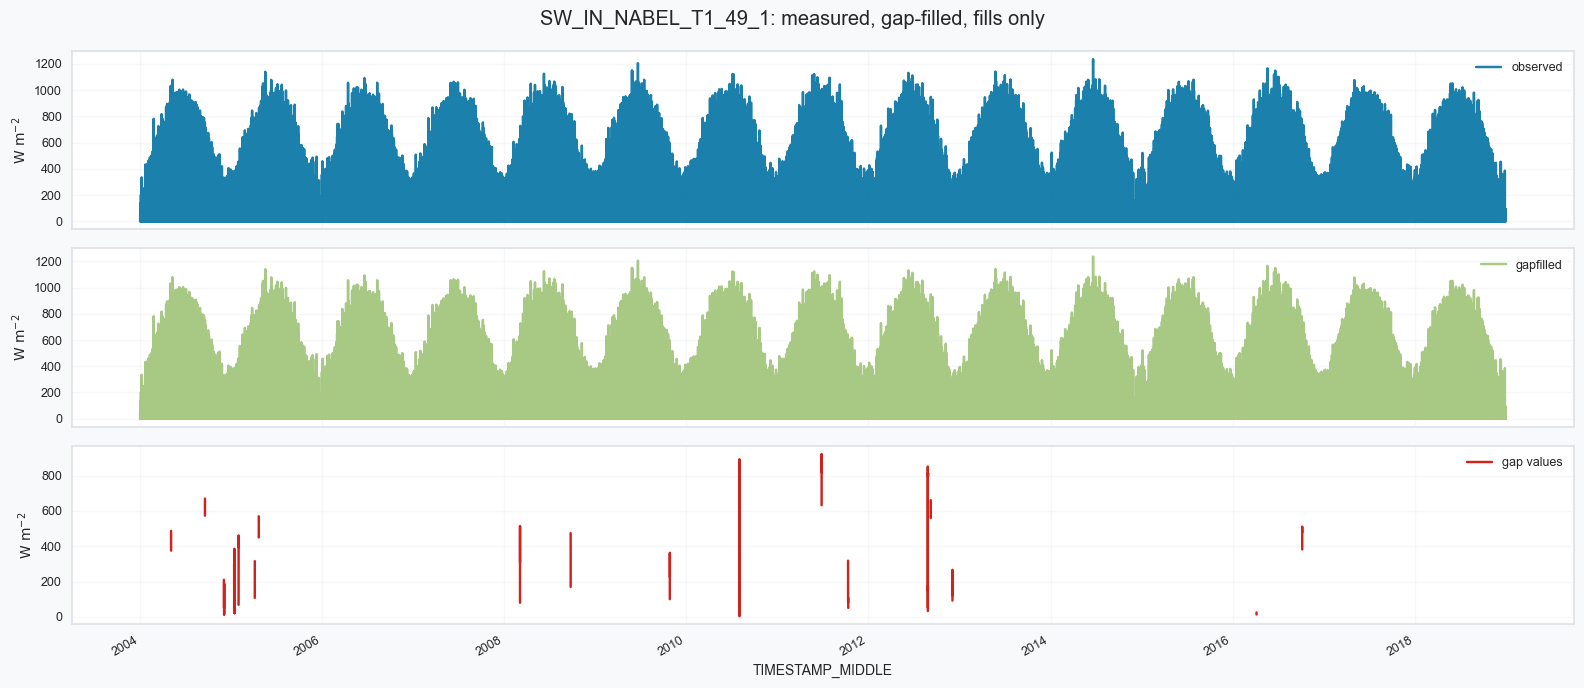

In [26]:
plot_gapfill_panels(gf_nabel.results, title="SW_IN_NABEL_T1_49_1: measured, gap-filled, fills only");

### Plot: predicted vs measured on held-out data

The model never saw these records during training, so this is the view that shows whether the
daytime model is actually any good. A tilt in the residual panel means bias; a widening cone means
the error grows with the value, which for radiation is expected.

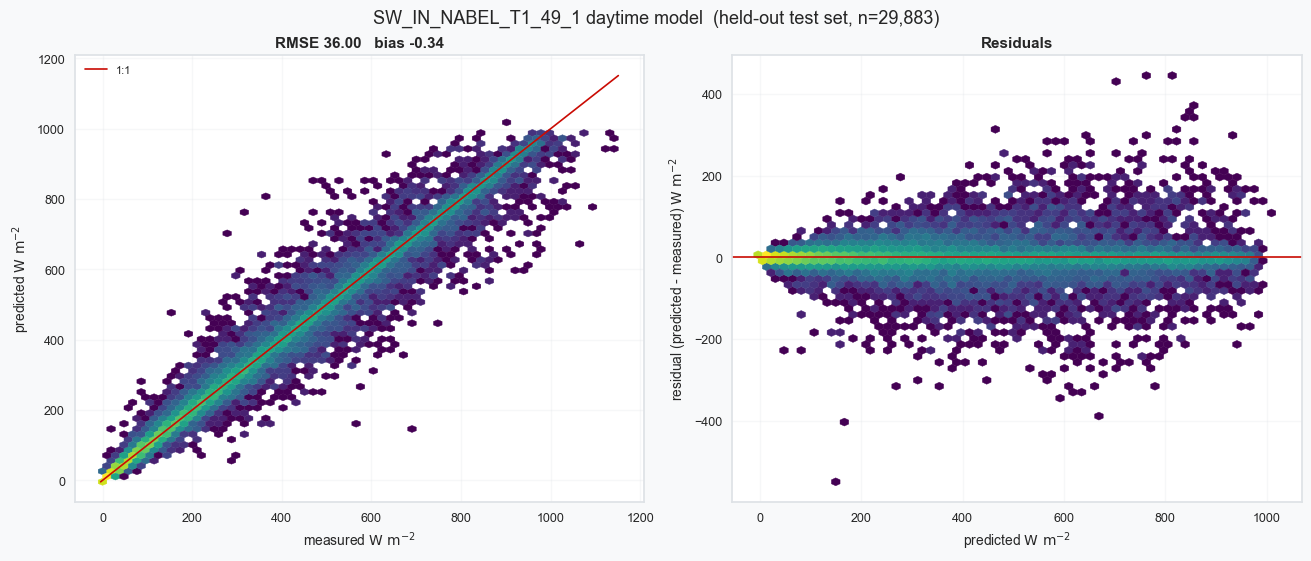

In [27]:
plot_pred_vs_measured(gf_nabel.daytime_model_, title="SW_IN_NABEL_T1_49_1 daytime model");

## Plot time series

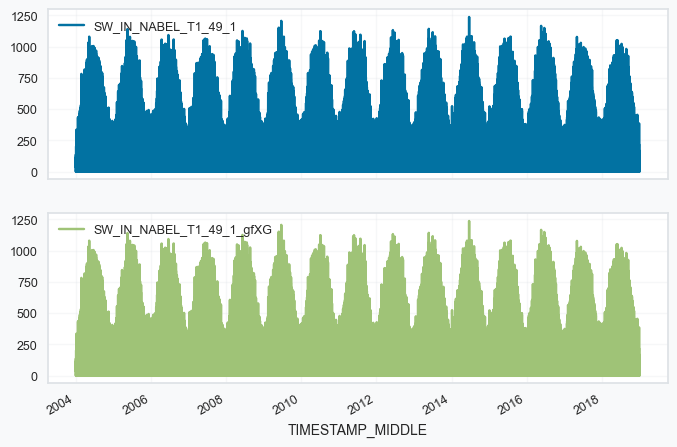

In [28]:
swin_2004_2018[[TARGET, gapfilled_nabel.name]].plot(subplots=True, x_compat=True);

***

# 🟥 Gap-filling ETH (2004-2018) using NABEL+
- NABEL is now complete (no gaps) 2004-2018 and can be used as feature in those years

## Run gap-filling

The gap-filled NABEL series is passed in as an additional driver via `context_df`; `SW_IN_POT`
and the timestamp features are added by the gap-filler itself.

NABEL is a second radiation measurement and is complete over these years, so it carries the sky
state that the timestamp cannot. This is the run where `interpolate_short_gaps='auto'` resolves
to *off* — see the note further up.

In [29]:
%%time

TARGET = "SW_IN_T1_47_1"

gf_eth_2004_2018 = dv.gapfilling.SWINGapFillerXGBoost(
    series=swin_2004_2018[TARGET],
    lat=SITE_LAT,
    lon=SITE_LON,
    utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS,
    context_df=swin_2004_2018[['SW_IN_NABEL_T1_49_1_gfXG']],  # NABEL as additional driver
    correct_nighttime_offset=True,
    # interpolate_short_gaps left at 'auto': a driver is given, so interpolation stays OFF and
    # does not overwrite the NABEL-informed model fills
    reduce_features=True,
    verbose=1,
    # XGBoost hyperparameters are left at the class defaults (n_estimators, max_depth,
    # early_stopping_rounds, random_state). They are tuned for SW_IN and keep a run
    # reproducible; only n_jobs is set here.
    n_jobs=-1,
)
gf_eth_2004_2018.run()

──────────────────────────────── SW_IN Gap-Filling (SW_IN_T1_47_1) ─────────────────────────────────

> running remove_nighttime_zero_offset ...

Output()

> Step 1: Correcting nighttime sensor offset (2.0s)

> Step 2: Computing potential radiation and day/night split (2.0s, 137361 daytime / 125631 
nighttime records)

...

> Step 6: Reducing features (SHAP vs random benchmark) and retraining (1.9s)

Output()

> Step 7: Filling daytime gaps (SHAP importances over full record) (0.7s)

v Done in 8.5s - 33155 records filled (33155 gaps total)

CPU times: total: 27.8 s
Wall time: 8.5 s


## Report

In [30]:
gf_eth_2004_2018.report()

───────────────────────────── SW_IN Gap-Filling Report: SW_IN_T1_47_1 ──────────────────────────────

Algorithm: physics-aware partitioning + XGBoost
    Nighttime gaps  -> set to 0 W m-2 (no incoming solar radiation)
    Daytime gaps    -> XGBoost trained on daytime observations
    Day/night split -> SW_IN_POT (potential radiation) vs threshold

──────────────────────────────────────────── Parameters ────────────────────────────────────────────

Site latitude              47.478333
  Site longitude             8.364389
  UTC offset                 1
  Nighttime threshold        0.001 W m-2  (SW_IN_POT < threshold -> night)
  Correct nighttime offset   True
  Reduce features (SHAP)     True
  context drivers            ['SW_IN_NABEL_T1_49_1_gfXG']

─────────────────────────────────────── Feature engineering ────────────────────────────────────────

...

MSE      921.2258

RMSE     30.3517

MAPE     64475394426112.4609

MAXE     836.8084

R2       0.9871

## Results: scores and feature importances

In [31]:
r = gf_eth_2004_2018.results
print("Daytime model, held-out (train/test) scores:")
display(pd.Series(r.scores_traintest))
print("Flag counts:")
display(r.flag.value_counts().sort_index().rename(index=FLAG_LEGEND))

Daytime model, held-out (train/test) scores:


mae      1.659053e+01
medae    6.351079e+00
mse      1.178631e+03
rmse     3.433119e+01
mape     7.232787e+13
maxe     8.368084e+02
r2       9.836248e-01
dtype: float64

Flag counts:


flag
0 = observed                                    229837
1 = daytime gap, filled by the XGBoost model     17708
3 = nighttime gap, set to zero by physics        15447
Name: count, dtype: int64

In [32]:
r.feature_importances

,SHAP_IMPORTANCE,SHAP_SD
SW_IN_NABEL_T1_49_1_gfXG,206.847946,132.873978
.SW_IN_NABEL_T1_49_1_gfXG_MEAN4,9.878800,11.771747
.SW_IN_NABEL_T1_49_1_gfXG_ROLLMEDIAN4,7.585938,6.612689
.SW_IN_NABEL_T1_49_1_gfXG_EMA6,3.462768,3.424565
.HOUR_SIN,3.156044,2.746126
.YEARMONTH,3.097212,3.037043
SW_IN_POT,2.072106,1.489783
.SW_IN_NABEL_T1_49_1_gfXG_MEAN48,1.742779,1.772908
.SW_IN_NABEL_T1_49_1_gfXG_MEAN8,1.667003,3.884734
.HOUR_COS,1.613355,1.503888


## Add gap-filled series to dataframe

In [33]:
gapfilled_eth_2004_2018 = gf_eth_2004_2018.results.gapfilled.rename(f"{TARGET}_gfXG")
swin_2004_2018[gapfilled_eth_2004_2018.name] = gapfilled_eth_2004_2018

# This flag IS exported (see the export section). Held as a standalone series rather than a
# dataframe column so the plotting cells below keep showing radiation only.
flag_eth_2004_2018 = gf_eth_2004_2018.results.flag.rename(f"FLAG_{TARGET}_ISFILLED")
display(flag_eth_2004_2018.value_counts().sort_index().rename(index=FLAG_LEGEND))

swin_2004_2018[[TARGET, gapfilled_eth_2004_2018.name]].describe()

FLAG_SW_IN_T1_47_1_ISFILLED
0 = observed                                    229837
1 = daytime gap, filled by the XGBoost model     17708
3 = nighttime gap, set to zero by physics        15447
Name: count, dtype: int64

,SW_IN_T1_47_1,SW_IN_T1_47_1_gfXG
count,229837.000000,262992.000000
mean,139.297168,143.682663
std,236.622688,237.383524
min,-16.722927,0.000000
25%,-3.153105,0.000000
50%,1.366153,4.157803
75%,187.130249,193.369528
max,1107.969487,1111.028655


### Plot: measured, gap-filled and the fills on their own

The bottom panel shows only the gap-filled values. Anything that looks wrong there — fills at an
implausible level, or a long block of fills — is worth following up, because it is invisible in
the combined series.

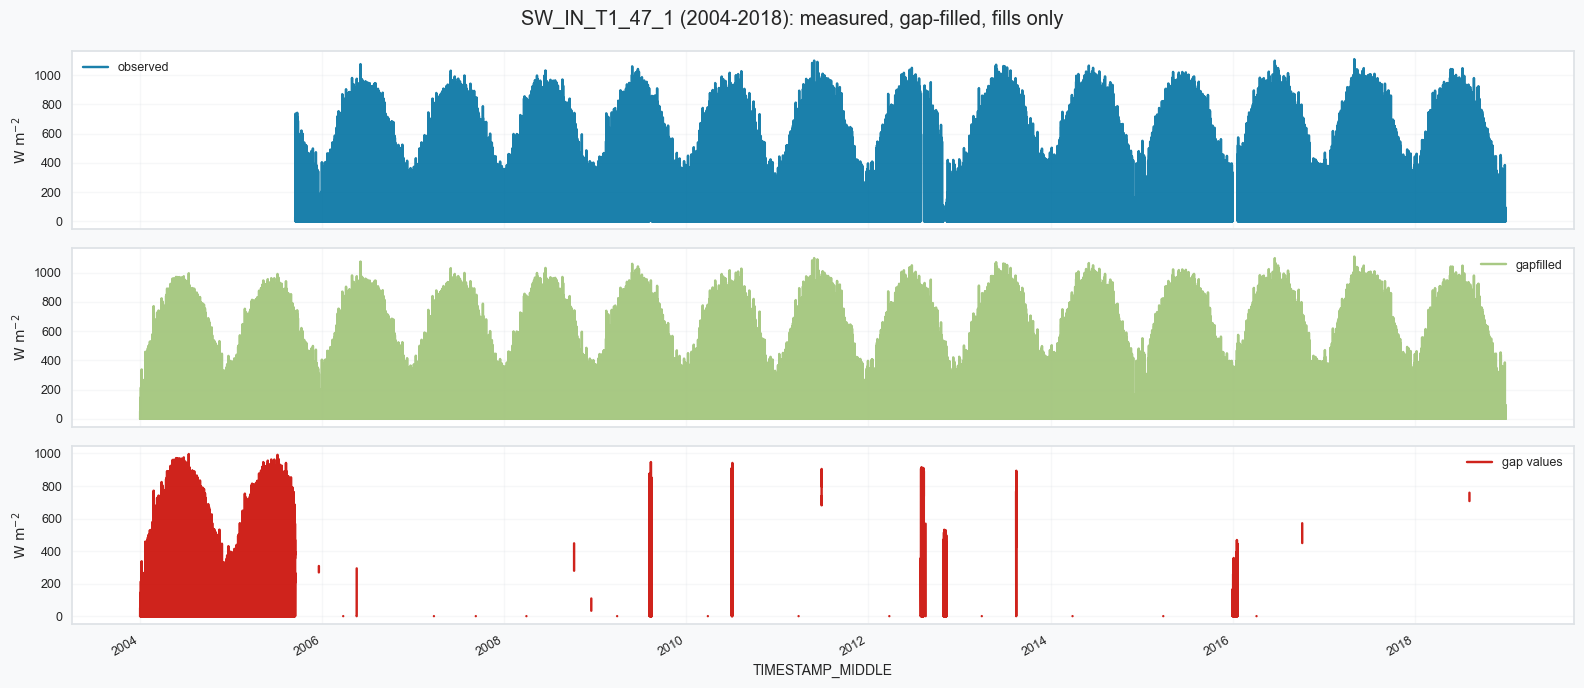

In [34]:
plot_gapfill_panels(gf_eth_2004_2018.results, title="SW_IN_T1_47_1 (2004-2018): measured, gap-filled, fills only");

### Plot: predicted vs measured on held-out data

The model never saw these records during training, so this is the view that shows whether the
daytime model is actually any good. A tilt in the residual panel means bias; a widening cone means
the error grows with the value, which for radiation is expected.

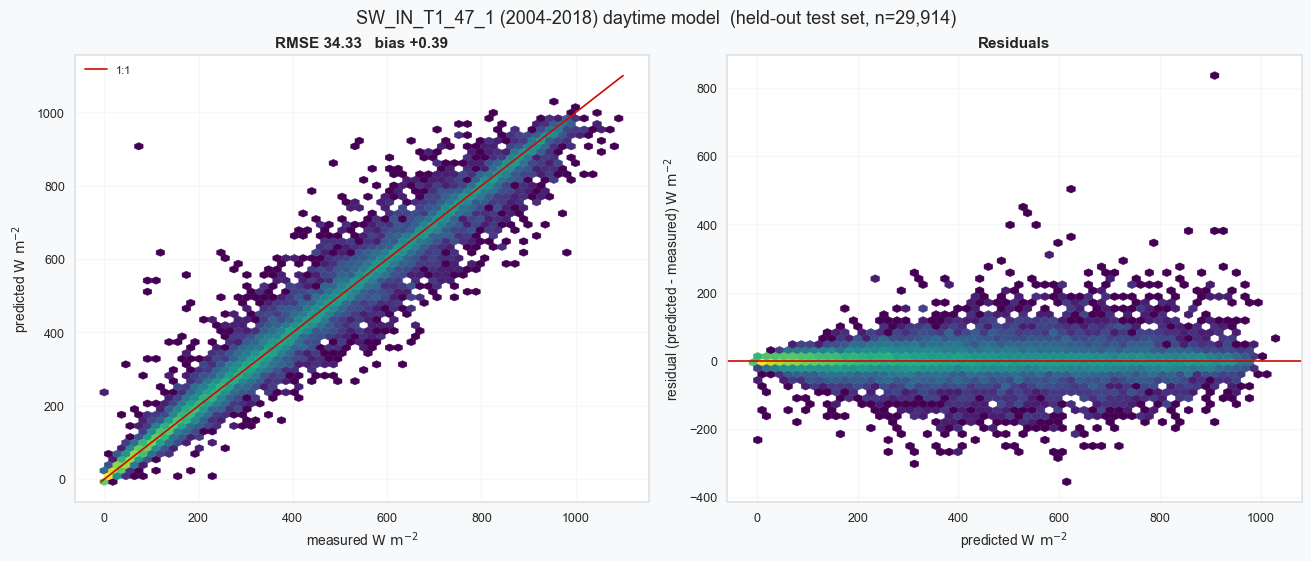

In [35]:
plot_pred_vs_measured(gf_eth_2004_2018.daytime_model_, title="SW_IN_T1_47_1 (2004-2018) daytime model");

## Dataframe

In [36]:
display(swin_2004_2018)
swin_2004_2018.describe()

,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1,SW_IN_NABEL_T1_49_1_gfXG,SW_IN_T1_47_1_gfXG
TIMESTAMP_MIDDLE,,,,
2004-01-01 00:15:00,NaN,0.0,0.0,0.0
2004-01-01 00:45:00,NaN,0.0,0.0,0.0
2004-01-01 01:15:00,NaN,0.0,0.0,0.0
2004-01-01 01:45:00,NaN,0.0,0.0,0.0
2004-01-01 02:15:00,NaN,0.0,0.0,0.0
...,...,...,...,...
2018-12-31 21:45:00,-2.486487,0.0,0.0,0.0
2018-12-31 22:15:00,-2.620216,0.0,0.0,0.0
2018-12-31 22:45:00,-2.352738,0.0,0.0,0.0


,SW_IN_T1_47_1,SW_IN_NABEL_T1_49_1,SW_IN_NABEL_T1_49_1_gfXG,SW_IN_T1_47_1_gfXG
count,229837.000000,262774.000000,262992.000000,262992.000000
mean,139.297168,140.037811,140.200746,143.682663
std,236.622688,233.701783,233.789203,237.383524
min,-16.722927,0.000000,0.000000,0.000000
25%,-3.153105,0.000000,0.000000,0.000000
50%,1.366153,2.506354,2.577312,4.157803
75%,187.130249,186.456335,186.981822,193.369528
max,1107.969487,1236.721293,1236.721293,1111.028655


***

# 🟥 Plots (2004-2018)

## Heatmap

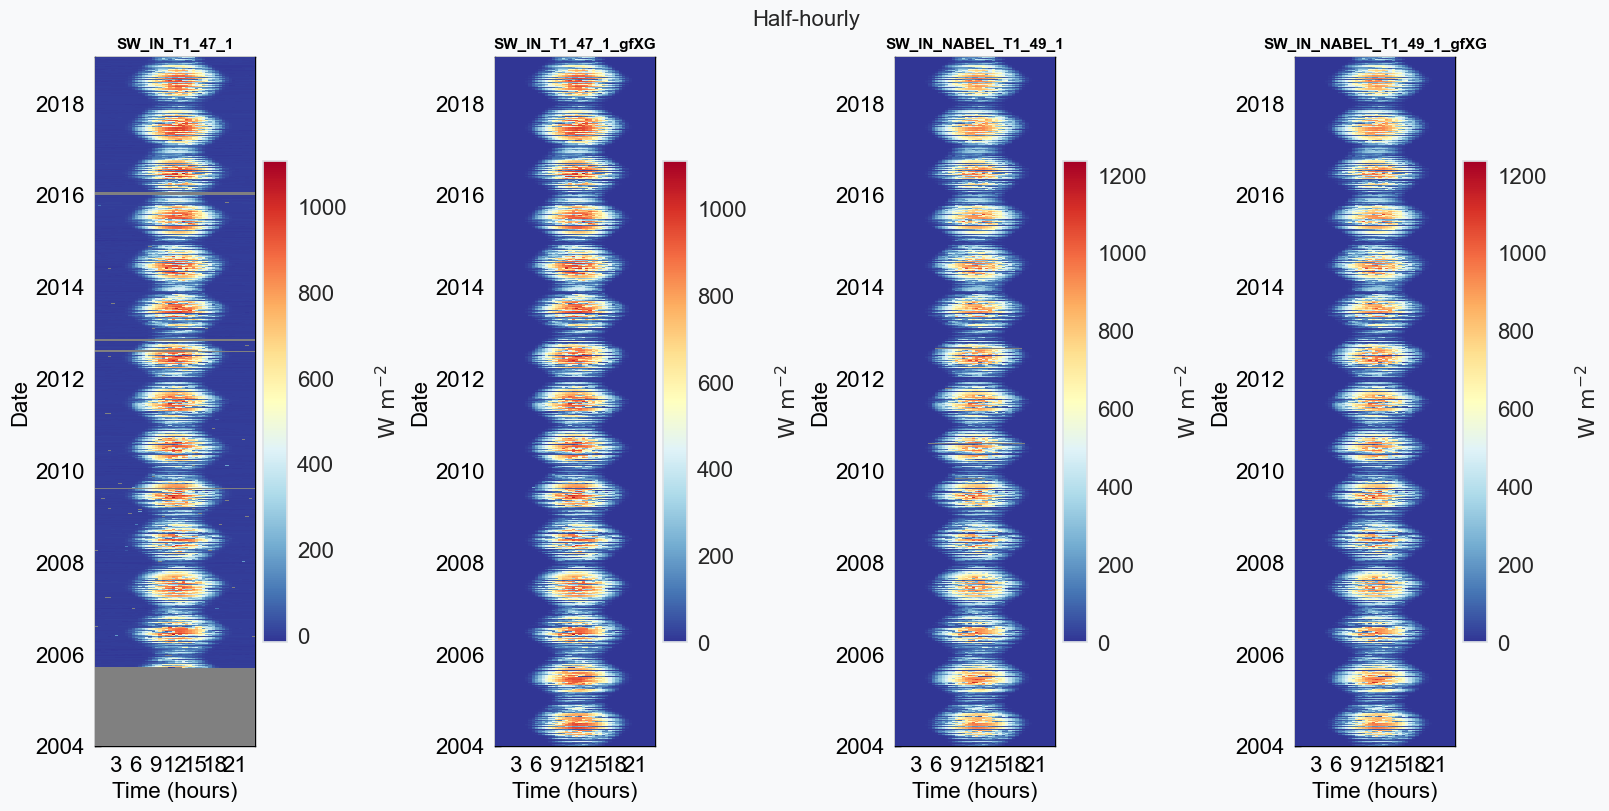

In [37]:
fig, axs = plt.subplots(ncols=4, figsize=(16, 8), dpi=100, layout="constrained")
fig.suptitle(f'Half-hourly', fontsize=16)
dv.plotting.HeatmapDateTime(series=swin_2004_2018['SW_IN_T1_47_1']).plot(
    ax=axs[0], cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
    format_style=dv.plotting.FormatStyle(title="SW_IN_T1_47_1", title_fontsize=11))
dv.plotting.HeatmapDateTime(series=swin_2004_2018['SW_IN_T1_47_1_gfXG']).plot(
    ax=axs[1], cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
    format_style=dv.plotting.FormatStyle(title="SW_IN_T1_47_1_gfXG", title_fontsize=11))
dv.plotting.HeatmapDateTime(series=swin_2004_2018['SW_IN_NABEL_T1_49_1']).plot(
    ax=axs[2], cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
    format_style=dv.plotting.FormatStyle(title="SW_IN_NABEL_T1_49_1", title_fontsize=11))
dv.plotting.HeatmapDateTime(series=swin_2004_2018['SW_IN_NABEL_T1_49_1_gfXG']).plot(
    ax=axs[3], cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
    format_style=dv.plotting.FormatStyle(title="SW_IN_NABEL_T1_49_1_gfXG", title_fontsize=11))

## Time series plot

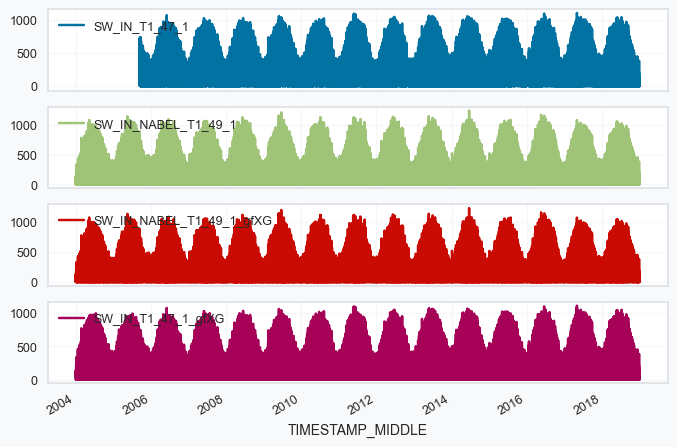

In [38]:
swin_2004_2018.plot(subplots=True, x_compat=True);

***

# 🟧 Gap-filling ETH (2019-2025)
- From mst (2019-2021) and diive meteoscreening (2022-2025)
- No NABEL data in this period, so only `SW_IN_POT` + timestamp features are used

::: {.callout-warning title="These fills are less accurate than 2004-2018"}
Measured `SW_IN` is the position of the sun multiplied by the state of the sky. The position of
the sun follows from the timestamp and the site coordinates — that is what `SW_IN_POT` is.
Cloudiness does not.

Without a second radiation sensor as a driver, everything the model sees is derived from the
clock. It can therefore only return the *typical* `SW_IN` for that time of day and year, and has
no way of knowing whether a particular gap was cloudy or clear. Adding more time-derived features
does not change this. Only a second sensor does, and there is none in this period.

Daytime gaps here are filled with a typical value rather than one that reflects the actual
weather. Nighttime fills (zero) and the short gaps filled by interpolation are not affected.
Read the flag column: flag `1` records in 2019-2025 are the least reliable part of the series.
:::

## Run gap-filling

In [39]:
%%time

TARGET = "SW_IN_T1_47_1"

gf_eth_2019_2025 = dv.gapfilling.SWINGapFillerXGBoost(
    series=swin_2019_2025[TARGET],
    lat=SITE_LAT,
    lon=SITE_LON,
    utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS,
    correct_nighttime_offset=True,
    # interpolate_short_gaps left at 'auto': no driver here, so it fills daytime gaps <= 2 records
    reduce_features=True,
    verbose=1,
    # XGBoost hyperparameters are left at the class defaults (n_estimators, max_depth,
    # early_stopping_rounds, random_state). They are tuned for SW_IN and keep a run
    # reproducible; only n_jobs is set here.
    n_jobs=-1,
)
gf_eth_2019_2025.run()

──────────────────────────────── SW_IN Gap-Filling (SW_IN_T1_47_1) ─────────────────────────────────

> running remove_nighttime_zero_offset ...

Output()

> Step 1: Correcting nighttime sensor offset (0.8s)

> Step 2: Computing potential radiation and day/night split (0.7s, 64107 daytime / 58629 nighttime
records)

...

> Step 7: Reducing features (SHAP vs random benchmark) and retraining (14.2s)

Output()

> Step 8: Filling daytime gaps (SHAP importances over full record) (6.4s)

v Done in 31.7s - 847 records filled (847 gaps total)

CPU times: total: 3min 23s
Wall time: 31.7 s


## Report

In [40]:
gf_eth_2019_2025.report()

───────────────────────────── SW_IN Gap-Filling Report: SW_IN_T1_47_1 ──────────────────────────────

Algorithm: physics-aware partitioning + XGBoost
    Nighttime gaps  -> set to 0 W m-2 (no incoming solar radiation)
    Daytime gaps    -> XGBoost trained on daytime observations
    Day/night split -> SW_IN_POT (potential radiation) vs threshold

──────────────────────────────────────────── Parameters ────────────────────────────────────────────

Site latitude              47.478333
  Site longitude             8.364389
  UTC offset                 1
  Nighttime threshold        0.001 W m-2  (SW_IN_POT < threshold -> night)
  Correct nighttime offset   True
  Reduce features (SHAP)     True
  context drivers            none

─────────────────────────────────────── Feature engineering ────────────────────────────────────────

...

MSE      6454.1454

RMSE     80.3377

MAPE     748596322118665.3750

MAXE     668.3923

R2       0.9147

## Results: scores and feature importances

In [41]:
r = gf_eth_2019_2025.results
print("Daytime model, held-out (train/test) scores:")
display(pd.Series(r.scores_traintest))
print("Flag counts:")
display(r.flag.value_counts().sort_index().rename(index=FLAG_LEGEND))

Daytime model, held-out (train/test) scores:


mae      6.981811e+01
medae    4.245534e+01
mse      1.101158e+04
rmse     1.049361e+02
mape     7.866030e+14
maxe     6.683923e+02
r2       8.573913e-01
dtype: float64

Flag counts:


flag
0 = observed                                                121889
1 = daytime gap, filled by the XGBoost model                   391
3 = nighttime gap, set to zero by physics                      447
4 = daytime gap, filled by clearness-index interpolation         9
Name: count, dtype: int64

In [42]:
r.feature_importances

,SHAP_IMPORTANCE,SHAP_SD
SW_IN_POT,179.705856,108.744766
.DOY_SIN,42.653912,37.261906
.YEARDOY,39.210278,33.299088
.RECORDNUMBER,38.411530,30.749620
.WEEK_SIN,36.371655,30.306444
.YEARWEEK,26.379728,22.307873
.DOY_COS,25.331776,23.478580
.YEARMONTH,16.505836,18.401058


## Add gap-filled series to dataframe

In [43]:
gapfilled_eth_2019_2025 = gf_eth_2019_2025.results.gapfilled.rename(f"{TARGET}_gfXG")
swin_2019_2025[gapfilled_eth_2019_2025.name] = gapfilled_eth_2019_2025

# This flag IS exported (see the export section).
flag_eth_2019_2025 = gf_eth_2019_2025.results.flag.rename(f"FLAG_{TARGET}_ISFILLED")
display(flag_eth_2019_2025.value_counts().sort_index().rename(index=FLAG_LEGEND))

swin_2019_2025[[TARGET, gapfilled_eth_2019_2025.name]].describe()

FLAG_SW_IN_T1_47_1_ISFILLED
0 = observed                                                121889
1 = daytime gap, filled by the XGBoost model                   391
3 = nighttime gap, set to zero by physics                      447
4 = daytime gap, filled by clearness-index interpolation         9
Name: count, dtype: int64

,SW_IN_T1_47_1,SW_IN_T1_47_1_gfXG
count,121889.000000,122736.000000
mean,146.704227,149.391040
std,244.842961,244.607265
min,-16.479040,0.000000
25%,0.000000,0.000000
50%,1.021432,3.606200
75%,202.106873,204.169091
max,1109.351433,1118.658439


### Plot: measured, gap-filled and the fills on their own

The bottom panel shows only the gap-filled values. Anything that looks wrong there — fills at an
implausible level, or a long block of fills — is worth following up, because it is invisible in
the combined series.

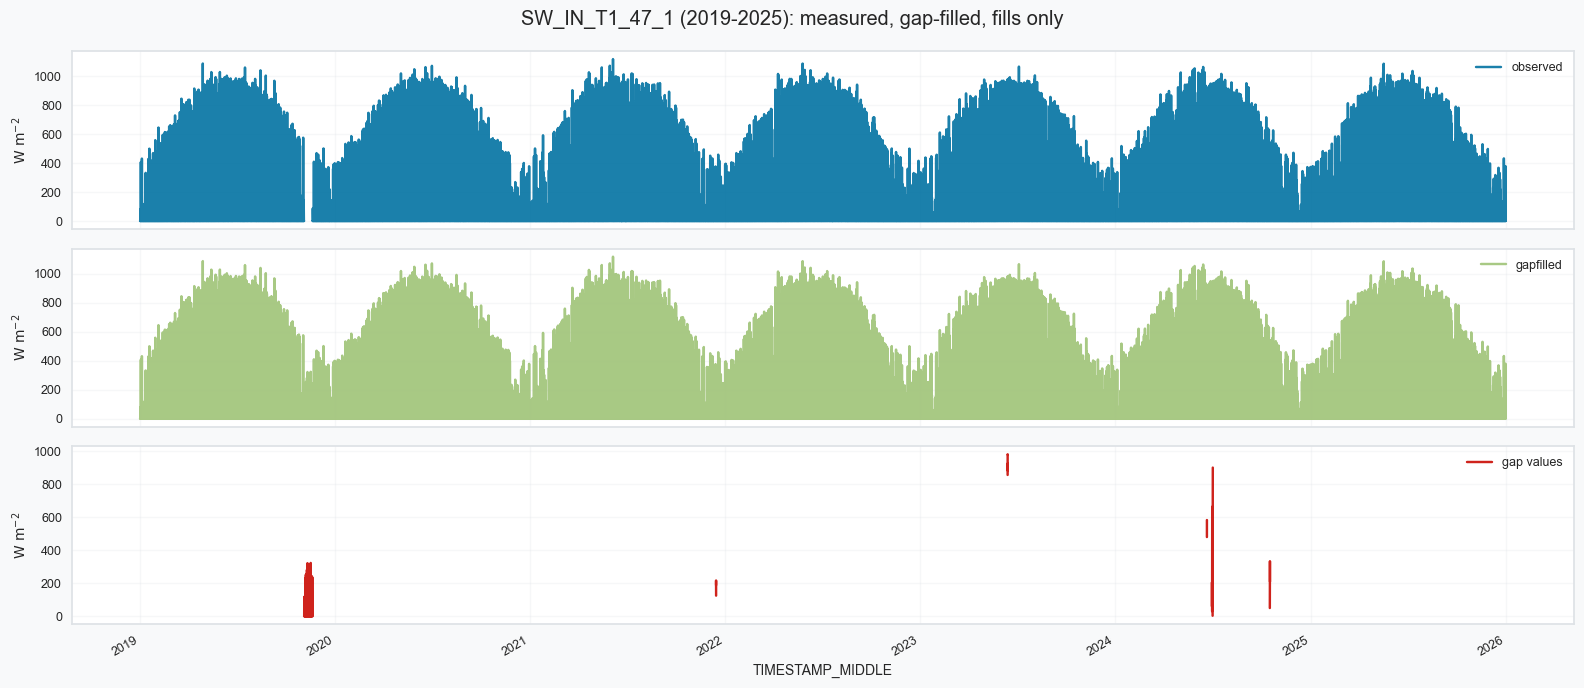

In [44]:
plot_gapfill_panels(gf_eth_2019_2025.results, title="SW_IN_T1_47_1 (2019-2025): measured, gap-filled, fills only");

### Plot: predicted vs measured on held-out data

The model never saw these records during training, so this is the view that shows whether the
daytime model is actually any good. A tilt in the residual panel means bias; a widening cone means
the error grows with the value, which for radiation is expected.

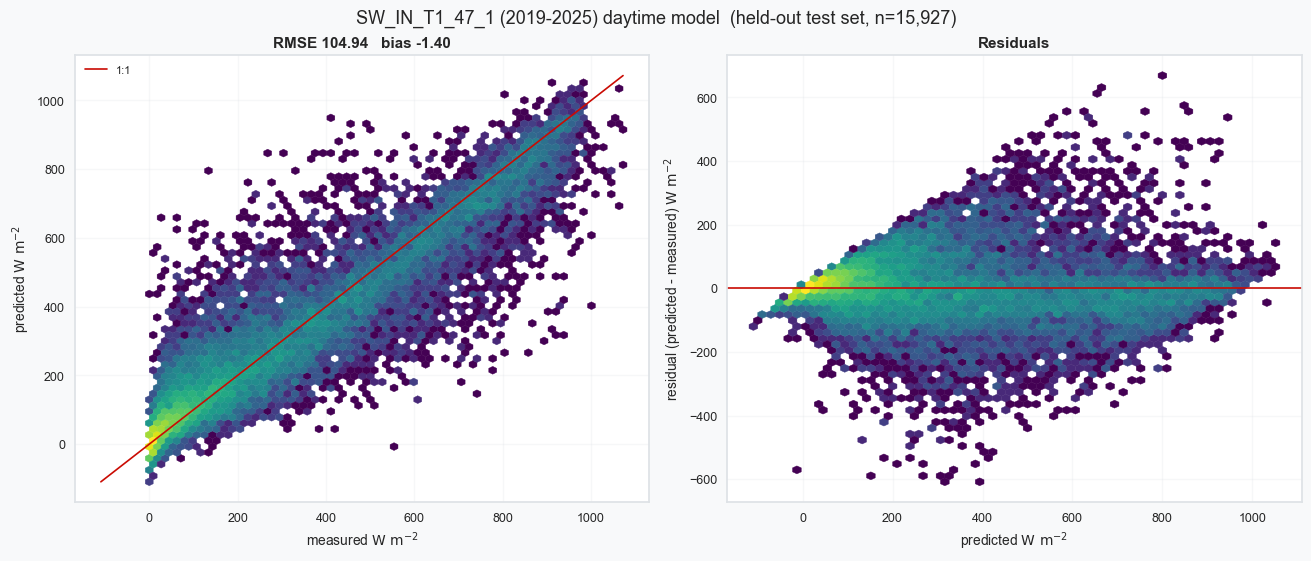

In [45]:
plot_pred_vs_measured(gf_eth_2019_2025.daytime_model_, title="SW_IN_T1_47_1 (2019-2025) daytime model");

## Plot time series

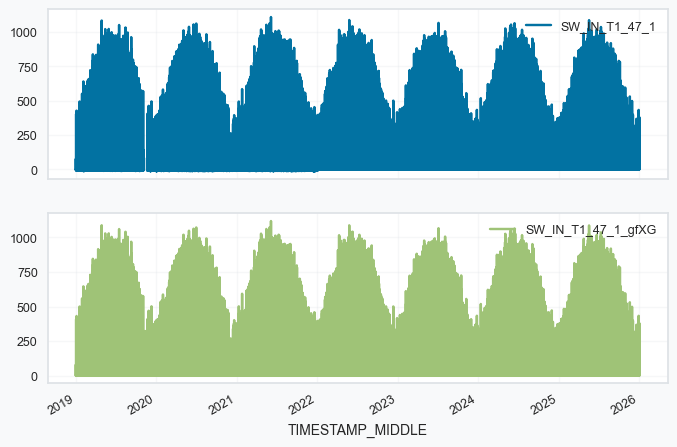

In [46]:
swin_2019_2025[[TARGET, gapfilled_eth_2019_2025.name]].plot(subplots=True, x_compat=True);

## Dataframe

In [47]:
display(swin_2019_2025)
swin_2019_2025.describe()

,SW_IN_T1_47_1,SW_IN_T1_47_1_gfXG
TIMESTAMP_MIDDLE,,
2019-01-01 00:15:00,-2.149965,0.0
2019-01-01 00:45:00,-2.722333,0.0
2019-01-01 01:15:00,-3.087591,0.0
2019-01-01 01:45:00,-2.410228,0.0
2019-01-01 02:15:00,-2.400173,0.0
...,...,...
2025-12-31 21:45:00,0.000000,0.0
2025-12-31 22:15:00,0.000000,0.0
2025-12-31 22:45:00,0.000000,0.0


,SW_IN_T1_47_1,SW_IN_T1_47_1_gfXG
count,121889.000000,122736.000000
mean,146.704227,149.391040
std,244.842961,244.607265
min,-16.479040,0.000000
25%,0.000000,0.000000
50%,1.021432,3.606200
75%,202.106873,204.169091
max,1109.351433,1118.658439


***

# ➡️ Prepare dataframe for export

In [48]:
VALCOL = "SW_IN_T1_47_1_gfXG"
FLAGCOL = "FLAG_SW_IN_T1_47_1_ISFILLED"

# Values and flags come from the same gap-filling run per period, so they are paired
# before the two periods are stacked.
export_df = pd.concat([
    pd.concat([swin_2004_2018[VALCOL], flag_eth_2004_2018], axis=1),
    pd.concat([swin_2019_2025[VALCOL], flag_eth_2019_2025], axis=1),
], axis=0)
export_df

,SW_IN_T1_47_1_gfXG,FLAG_SW_IN_T1_47_1_ISFILLED
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,0.0,3
2004-01-01 00:45:00,0.0,3
2004-01-01 01:15:00,0.0,3
2004-01-01 01:45:00,0.0,3
2004-01-01 02:15:00,0.0,3
...,...,...
2025-12-31 21:45:00,0.0,0
2025-12-31 22:15:00,0.0,0
2025-12-31 22:45:00,0.0,0


Sanity check: the exported series must be complete (no gaps) and non-negative, the index must be
continuous 30MIN with no duplicates, and every record must carry a flag.

`FLAG_SW_IN_T1_47_1_ISFILLED` travels with the product so the downstream notebooks can tell
measured from filled records. Flag `0` is measured, everything above `0` is filled by the method
given in `FLAG_LEGEND`.

In [49]:
print(f"Records:         {len(export_df)}")
print(f"Missing values:  {export_df[VALCOL].isnull().sum()}")
print(f"Negative values: {(export_df[VALCOL] < 0).sum()}")
print(f"Missing flags:   {export_df[FLAGCOL].isnull().sum()}")
print(f"Duplicate index: {export_df.index.duplicated().sum()}")
print(f"Index gaps:      {(export_df.index.to_series().diff().dropna() != pd.Timedelta('30min')).sum()}")

print("\nFill provenance:")
_counts = export_df[FLAGCOL].value_counts().sort_index()
_pct = 100 * _counts / len(export_df)
display(pd.DataFrame({'count': _counts, '%': _pct.round(2)}).rename(index=FLAG_LEGEND))
print(f"Measured: {100 * (export_df[FLAGCOL] == 0).mean():.2f}%  |  "
      f"Filled: {100 * (export_df[FLAGCOL] > 0).mean():.2f}%")

export_df.describe()

Records:         385728
Missing values:  0
Negative values: 0
Missing flags:   0
Duplicate index: 0
Index gaps:      0

Fill provenance:


,count,%
FLAG_SW_IN_T1_47_1_ISFILLED,,
0 = observed,351726,91.18
"1 = daytime gap, filled by the XGBoost model",18099,4.69
"3 = nighttime gap, set to zero by physics",15894,4.12
"4 = daytime gap, filled by clearness-index interpolation",9,0.00


Measured: 91.18%  |  Filled: 8.82%


,SW_IN_T1_47_1_gfXG,FLAG_SW_IN_T1_47_1_ISFILLED
count,385728.000000,385728.000000
mean,145.499029,0.170631
std,239.720112,0.623721
min,0.000000,0.000000
25%,0.000000,0.000000
50%,4.008015,0.000000
75%,196.845521,0.000000
max,1118.658439,4.000000


## Gap-filling overview

Where the fills sit in the record, and whether they behave like the measured data. In the monthly
means panel the two lines should track each other; a systematic gap between them means the fills
are biased relative to the measurements.

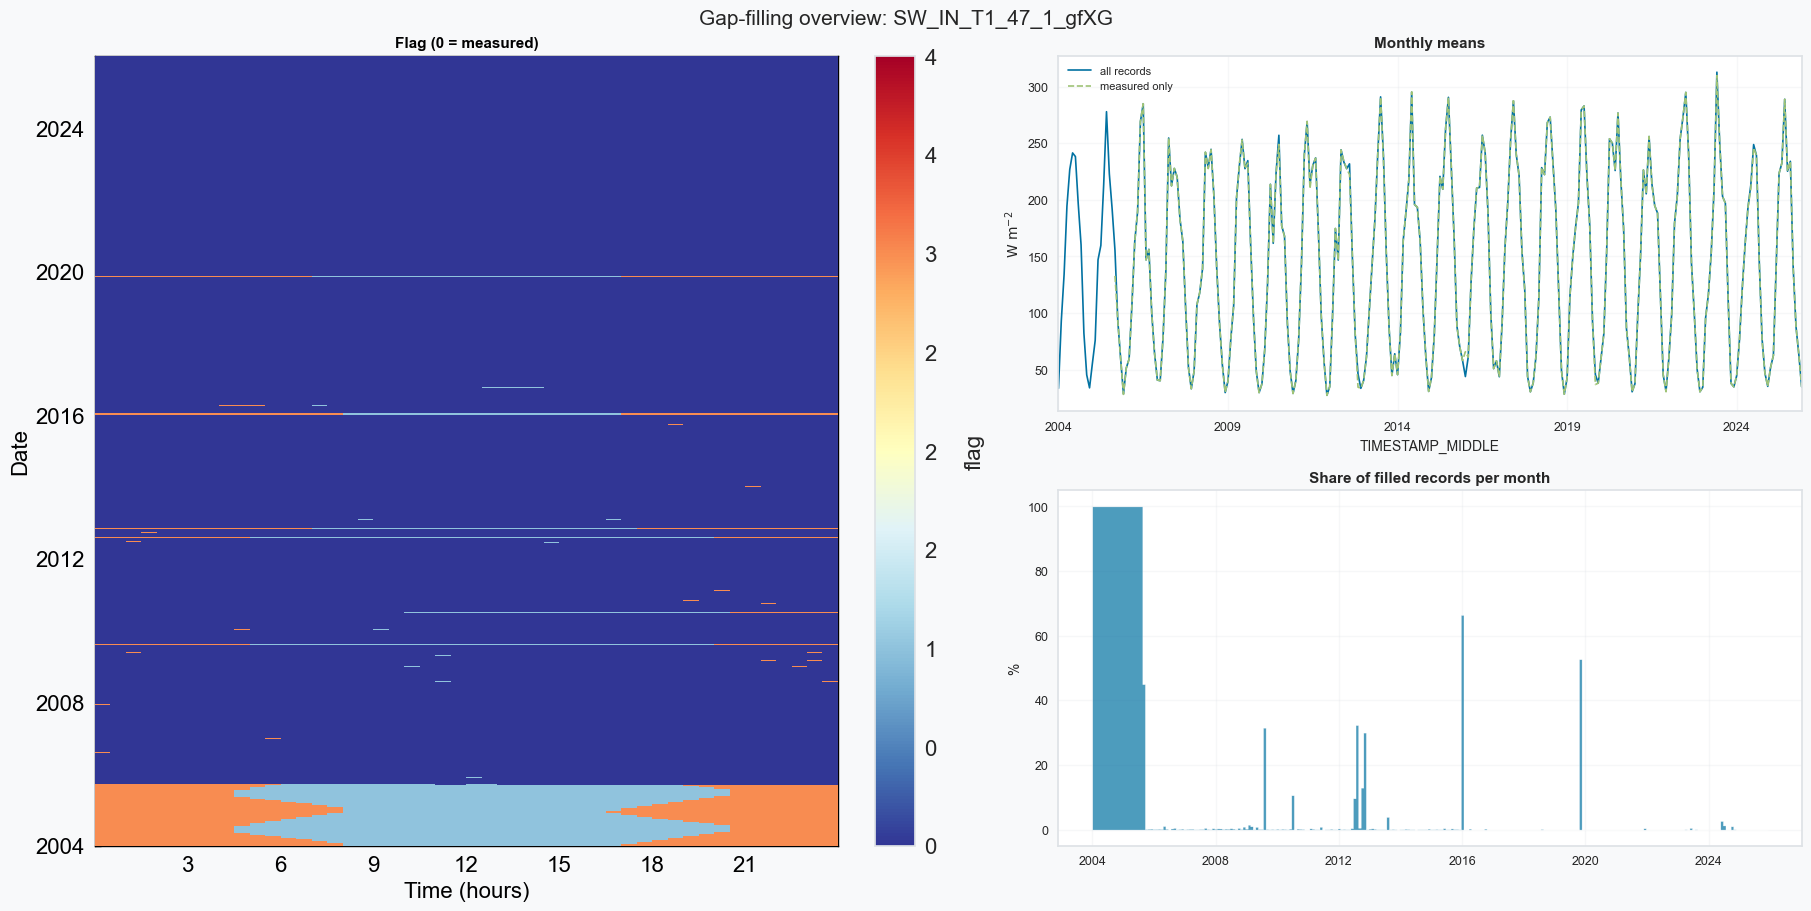

In [50]:
plot_fill_overview(export_df[VALCOL], export_df[FLAGCOL], label=VALCOL);

## Fill statistics per year

The table counts records per year and flag; the bars show the filled ones only. This is where an
uneven distribution of fills across the record becomes obvious.

,0 = observed,"1 = daytime gap, filled by the XGBoost model","3 = nighttime gap, set to zero by physics","4 = daytime gap, filled by clearness-index interpolation"
year,,,,
2004,0,9169,8399,0
2005,5199,6919,5402,0
2006,17473,17,30,0
2007,17489,15,16,0
2008,17513,27,28,0
2009,16989,310,221,0
2010,17339,119,62,0
2011,17491,17,12,0
2012,16293,666,609,0


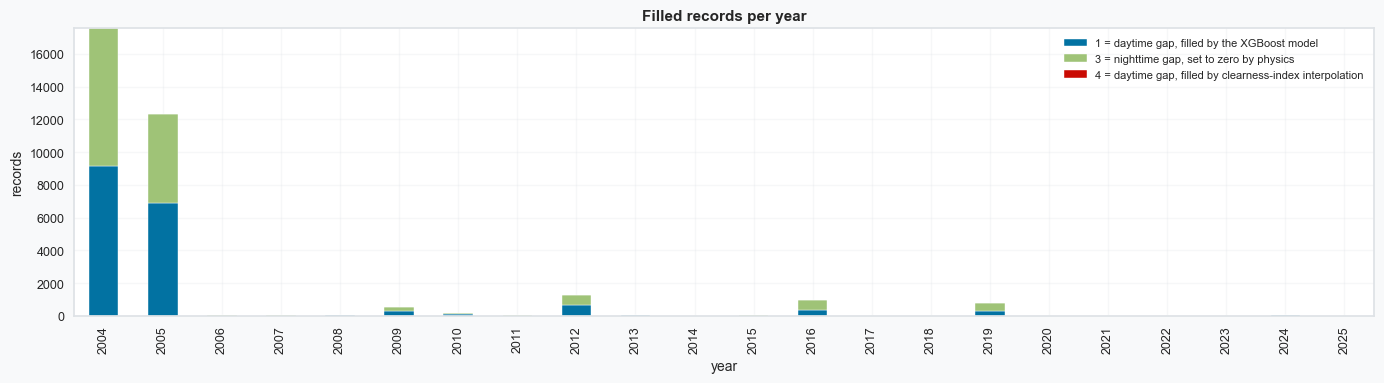

In [51]:
fill_stats_by_year(export_df[FLAGCOL])

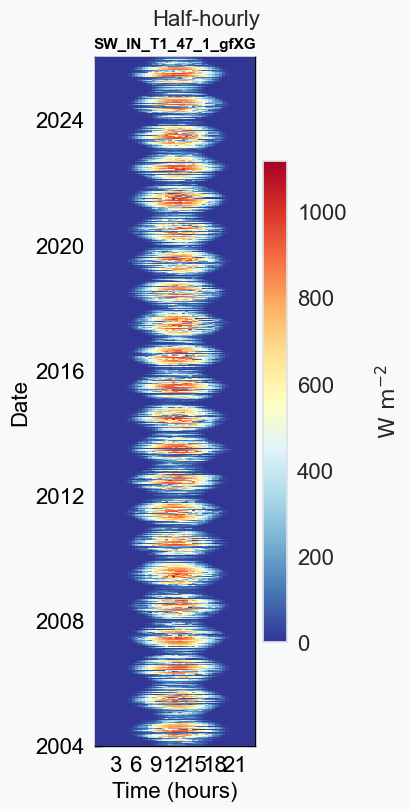

In [52]:
fig, axs = plt.subplots(ncols=1, figsize=(4, 8), dpi=100, layout="constrained")
fig.suptitle(f'Half-hourly', fontsize=16)
dv.plotting.HeatmapDateTime(series=export_df[VALCOL]).plot(
    ax=axs, cb_digits_after_comma=0, zlabel=r'$\mathrm{W\ m^{-2}}$',
    format_style=dv.plotting.FormatStyle(title=VALCOL, title_fontsize=11))

***

# 💾 Save to file

In [53]:
filepath = dv.save_parquet(filename=OUTNAME, data=export_df, outpath=OUTPATH)
export_df.to_csv(Path(OUTPATH) / f"{OUTNAME}.csv")
print(f"Saved to: {filepath}")

> Saved file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\01_METEO
_SW_IN_GAPFILLED_2004-2025.parquet (0.070 seconds).

Saved to: F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\01_METEO_SW_IN_GAPFILLED_2004-2025.parquet


***

# End of notebook.

In [54]:
NOTEBOOK_END = datetime.now()
_h, _rem = divmod(int((NOTEBOOK_END - NOTEBOOK_START).total_seconds()), 3600)
_m, _s = divmod(_rem, 60)

print(f"Started:  {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Finished: {NOTEBOOK_END.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Runtime:  {_h:02d}:{_m:02d}:{_s:02d} (hh:mm:ss)")

Started:  2026-07-19 23:23:43
Finished: 2026-07-19 23:25:26
Runtime:  00:01:42 (hh:mm:ss)
